In [1]:
import glob

import cartopy.crs as ccrs
import cftime
import cmocean as cmo
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import momlevel as ml
import numpy as np
import om4labs.om4common as om4
import pandas as pd
import scipy.signal as signal
import xarray as xr
from scipy.stats import linregress

# parameters for setting circular cutoff for Southern Ocean plots
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

out_path_fig = "/work/Katherine.Turner/stormtrack_variability/figures/"
out_path_data = "/work/Katherine.Turner/stormtrack_variability/data/"


def regress(y, x):
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    return slope  # or return r_value, p_value, etc.


def get_SAM_residuals(SAM_index, da):
    # Apply regression across lat/lon grid
    slope_map = xr.apply_ufunc(
        regress,
        da,
        SAM_index,
        input_core_dims=[["time"], ["time"]],
        vectorize=True,
        dask="parallelized",  # optional: speeds things up with dask
        output_dtypes=[float],
    )

    resid = da - da.mean(dim="time") - SAM_index * slope_map
    return resid, slope_map

In [107]:
mod = "ESM4"

# getting SAM indices
SAM = {}
season = ["DJF", "JJA"]

low_SAM = {}
high_SAM = {}

for s in season:
    ds = xr.open_dataset(
        f"/work/Katherine.Turner/stormtrack_variability/data/{mod}_cmip_{s}_SAM.nc"
    )

    if mod == "ESM4":
        if s == "DJF":
            SAM[s] = ds.pcs[1:-1, 0]
        else:
            SAM[s] = ds.pcs[:, 0]

    if mod == "CM4":
        if s == "DJF":
            SAM[s] = ds.pcs[151:-1, 0]
        else:
            SAM[s] = ds.pcs[150:, 0]
            
    low_SAM[s] = SAM[s].sortby(SAM[s]).time[:50]
    high_SAM[s] = SAM[s].sortby(SAM[s]).time[-50:]

In [108]:
ds = xr.open_dataset(
    f"/work/Katherine.Turner/stormtrack_variability/data/{mod}_cmip_monthly_storms.nc",
    use_cftime=True,
)

storms_seasonal = ds.center_counts.resample(time="QS-DEC").sum()

idx_jja = storms_seasonal.time.dt.month == 6
idx_djf = storms_seasonal.time.dt.month == 12

storms_djf = (
    storms_seasonal[idx_djf][1:-1] - storms_seasonal[idx_djf][1:-1].mean()
) / storms_seasonal[idx_djf][1:-1].std()
storms_jja = (
    storms_seasonal[idx_jja] - storms_seasonal[idx_jja].mean()
) / storms_seasonal[idx_jja].std()

STV = {}
STV["DJF"] = storms_djf
STV["JJA"] = storms_jja

low_storms = {}
high_storms = {}

low_storms["DJF"] = storms_djf.sortby(storms_djf).time[:50]
high_storms["DJF"] = storms_djf.sortby(storms_djf).time[-50:]

low_storms["JJA"] = storms_jja.sortby(storms_jja).time[:50]
high_storms["JJA"] = storms_jja.sortby(storms_jja).time[-50:]

## Distributions of integrated heat fluxes for all years and high/low index years

In [68]:
vd = {
    "hfds": {
        "realm": "ocean_monthly_1x1deg",
        "v_DJF": 10,
        "v_JJA": 20,
        "units": "W m$^{-2}$",
        "title": "$F_{heat}$",
    },
}

In [109]:
var = "hfds"
realm = vd[var]["realm"]

ds_v = xr.open_mfdataset(
    f"/work/Katherine.Turner/tempest-extremes/{mod}_cmip/data/{realm}*{var}.nc",
    use_cftime=True,
)

da_v = ds_v[var]

da_v_s = da_v.resample(time="QS-DEC").sum()

da = {}

da["DJF"] = (da_v_s[4:-4:4, :, :] / 3).compute()
da["JJA"] = (da_v_s[2::4, :, :] / 3).compute()

da_resid = {}
slope = {}

idx_high = {}
idx_low = {}

In [110]:
for s in season:
    da_resid[s], slope[s] = get_SAM_residuals(SAM[s], da[s])

    idx_high[s] = da_resid[s].time.dt.year.isin(high_storms[s].dt.year)
    idx_low[s] = da_resid[s].time.dt.year.isin(low_storms[s].dt.year)
    #idx_high[s] = da_resid[s].time.dt.year.isin(high_SAM[s].dt.year)
    #idx_low[s] = da_resid[s].time.dt.year.isin(low_SAM[s].dt.year)

In [111]:
ds_static = xr.open_dataset(f"/work5/k2t/tempest-extremes/{mod}_cmip/data/ocean_monthly_1x1deg.static.nc")

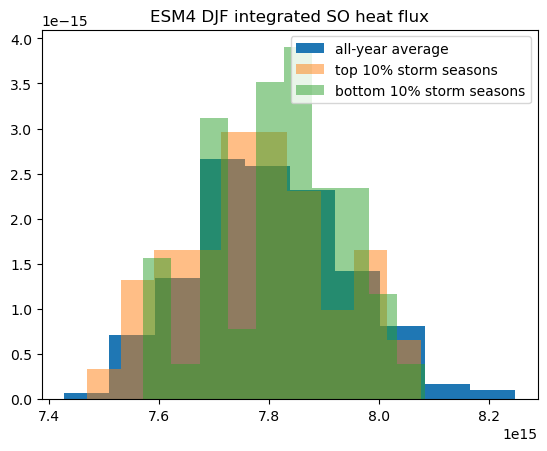

In [113]:
s = 'DJF'
(da[s] * ds_static.areacello).sel(lat=slice(-90,-40)).sum(dim=['lon','lat']).plot.hist(density=True, label='all-year average')
(da[s][idx_high[s], :, :] * ds_static.areacello).sel(lat=slice(-90,-40)).sum(dim=['lon','lat']).plot.hist(density=True, alpha=0.5, label='top 10% storm seasons')
(da[s][idx_low[s], :, :] * ds_static.areacello).sel(lat=slice(-90,-40)).sum(dim=['lon','lat']).plot.hist(density=True, alpha=0.5, label='bottom 10% storm seasons')

plt.legend()
plt.title(f"{mod} {s} integrated SO heat flux")

plt.savefig(f'/work/Katherine.Turner/stormtrack_variability/figures/SAM_sensitivity_comparison/{mod}_{s}_fheat_storm.png', format='png', dpi=150)

In [76]:
high_flx = (da[s][idx_high[s], :, :] * ds_static.areacello).sel(lat=slice(-90,-40)).sum(dim=['lon','lat']).mean(dim='time')
low_flx = (da[s][idx_low[s], :, :] * ds_static.areacello).sel(lat=slice(-90,-40)).sum(dim=['lon','lat']).mean(dim='time')
avg_flx = (da[s][~idx_high[s] & ~idx_low[s], :, :] * ds_static.areacello).sel(lat=slice(-90,-40)).sum(dim=['lon','lat']).mean(dim='time')

In [77]:
f"{high_flx.data - avg_flx.data :.2e}", f"{low_flx.data - avg_flx.data :.2e}", avg_flx.data

('-2.44e+13', '-3.92e+13', array(7.795499e+15, dtype=float32))

In [62]:
(da[s] * ds_static.areacello).sel(lat=slice(-90,-40)).sum(dim=['lon','lat']).std(dim='time')

<xarray.DataArray ()>
array(1.40853486e+14)

In [58]:
mod

'ESM4'